# TP3 - Arquitectura Personalizada

# Carga y preprocesamiento de imágenes

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/My Drive')

In [ ]:
!unzip 'landscapes_dataset.zip' -d '/content/drive/My Drive/'

Se truncaron las últimas líneas 5000 del resultado de transmisión.
  inflating: /content/drive/My Drive/landscapes_dataset/train/buildings/buildings (644).jpg  
  inflating: /content/drive/My Drive/landscapes_dataset/train/buildings/buildings (645).jpg  
  inflating: /content/drive/My Drive/landscapes_dataset/train/buildings/buildings (646).jpg  
  inflating: /content/drive/My Drive/landscapes_dataset/train/buildings/buildings (647).jpg  
  inflating: /content/drive/My Drive/landscapes_dataset/train/buildings/buildings (648).jpg  
  inflating: /content/drive/My Drive/landscapes_dataset/train/buildings/buildings (649).jpg  
  inflating: /content/drive/My Drive/landscapes_dataset/train/buildings/buildings (65).jpg  
  inflating: /content/drive/My Drive/landscapes_dataset/train/buildings/buildings (650).jpg  
  inflating: /content/drive/My Drive/landscapes_dataset/train/buildings/buildings (651).jpg  
  inflating: /content/drive/My Drive/landscapes_dataset/train/buildings/buildings (652).

In [ ]:
import tensorflow as tf
import numpy as np

# Definir el directorio del dataset
dataset_dir = '/content/drive/My Drive/landscapes_dataset/'  # Ajusta la ruta según corresponda

# Función para cargar un conjunto de datos desde un subdirectorio
def load_dataset(subdir):
    return tf.keras.preprocessing.image_dataset_from_directory(
        dataset_dir + subdir,
        labels='inferred',
        label_mode='int',  # Etiquetas como enteros
        image_size=(150, 150),  # Tamaño al que se redimensionarán las imágenes
        batch_size=32  # Tamaño de los lotes
    )

# Cargar los datasets de entrenamiento, validación y prueba
train_ds = load_dataset('train')
valid_ds = load_dataset('valid')
test_ds = load_dataset('test')

# Función para convertir un dataset de TensorFlow a arrays de Numpy
def dataset_to_numpy(dataset):
    data = []
    labels = []
    for images, labels_batch in dataset:
        data.extend(images.numpy())
        labels.extend(labels_batch.numpy())
    return np.array(data), np.array(labels)

# Convertir los datasets a Numpy arrays
train_data, train_labels = dataset_to_numpy(train_ds)
valid_data, valid_labels = dataset_to_numpy(valid_ds)
test_data, test_labels = dataset_to_numpy(test_ds)

print('Training data shape : ', train_data.shape, train_labels.shape)
print('Validation data shape : ', valid_data.shape, valid_labels.shape)
print('Test data shape : ', test_data.shape, test_labels.shape)

Found 6000 files belonging to 3 classes.
Found 600 files belonging to 3 classes.
Found 600 files belonging to 3 classes.
Training data shape :  (6000, 150, 150, 3) (6000,)
Validation data shape :  (600, 150, 150, 3) (600,)
Test data shape :  (600, 150, 150, 3) (600,)


In [ ]:
# Reshape
train_data = train_data.reshape(-1, 150, 150, 3)

test_data = test_data.reshape(-1, 150, 150, 3)

valid_data = valid_data.reshape(-1, 150, 150, 3)

train_data.shape, test_data.shape, valid_data.shape

((6000, 150, 150, 3), (600, 150, 150, 3), (600, 150, 150, 3))

In [ ]:
# Contar las etiquetas de cada clase en el conjunto de entrenamiento
unique_train, counts_train = np.unique(train_labels, return_counts=True)
train_label_counts = dict(zip(unique_train, counts_train))

# Contar las etiquetas de cada clase en el conjunto de prueba
unique_test, counts_test = np.unique(test_labels, return_counts=True)
test_label_counts = dict(zip(unique_test, counts_test))

# Contar las etiquetas de cada clase en el conjunto de prueba
unique_test, counts_test = np.unique(valid_labels, return_counts=True)
valid_label_counts = dict(zip(unique_test, counts_test))

# Imprimir el conteo de cada clase
print('Training set label counts:', train_label_counts)
print('Test set label counts:', test_label_counts)
print('Test set label counts:', valid_label_counts)

Training set label counts: {0: 2000, 1: 2000, 2: 2000}
Test set label counts: {0: 200, 1: 200, 2: 200}
Test set label counts: {0: 200, 1: 200, 2: 200}


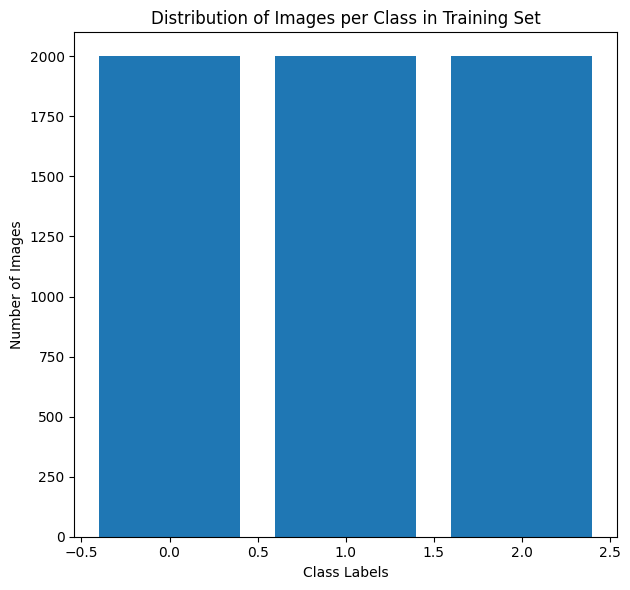

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(train_label_counts.keys(), train_label_counts.values())
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Class in Training Set')

plt.tight_layout()
plt.show()

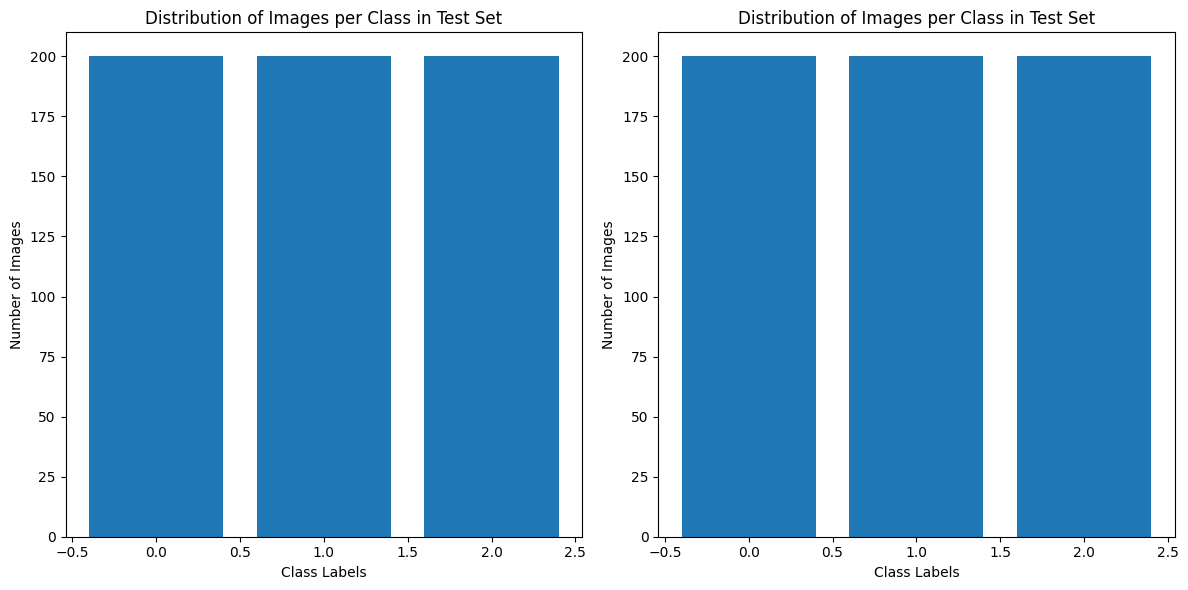

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(test_label_counts.keys(), test_label_counts.values())
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Class in Test Set')

plt.subplot(1, 2, 2)
plt.bar(valid_label_counts.keys(), valid_label_counts.values())
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Class in Test Set')

plt.tight_layout()
plt.show()

In [ ]:
from keras.utils import to_categorical
size = (224, 224)

train_X = tf.image.resize(train_data, (224, 224))
test_X = tf.image.resize(test_data, (224, 224))
valid_X = tf.image.resize(valid_data, (224, 224))

train_Y = to_categorical(train_labels, num_classes=3)
test_Y = to_categorical(test_labels, num_classes=3)
valid_Y = to_categorical(valid_labels, num_classes=3)

print(train_X.shape)
print(train_Y.shape)
print(test_X.shape)
print(test_Y.shape)
print(valid_X.shape)
print(valid_Y.shape)

# Mostrar la imagen 0
print('Original label (train):', train_labels[0])
print('After conversion to one-hot:', train_Y[0])
print('Original label (test):', test_labels[0])
print('After conversion to one-hot:', test_Y[0])
print('Original label (valid):', valid_labels[0])
print('After conversion to one-hot:', valid_Y[0])

(6000, 224, 224, 3)
(6000, 3)
(600, 224, 224, 3)
(600, 3)
(600, 224, 224, 3)
(600, 3)
Original label (train): 0
After conversion to one-hot: [1. 0. 0.]
Original label (test): 0
After conversion to one-hot: [1. 0. 0.]
Original label (valid): 0
After conversion to one-hot: [1. 0. 0.]


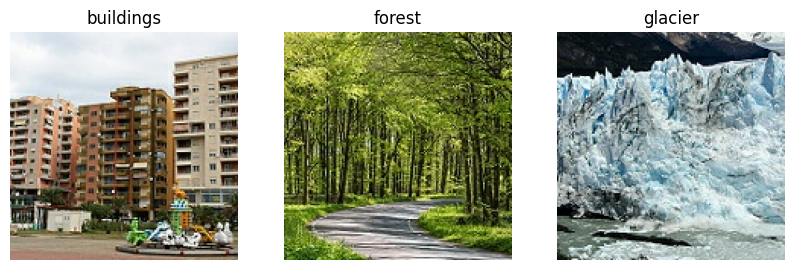

In [ ]:
def show_one_image_per_class(images, labels, class_names):
    unique_labels = np.unique(labels)
    plt.figure(figsize=(10, 10))
    for label in unique_labels:
        idx = np.where(labels == label)[0][0]  # Selecciona el primer índice para la clase
        plt.subplot((len(unique_labels) + 2) // 3, 3, label + 1)
        plt.imshow(images[idx].astype("uint8"))
        plt.title(class_names[label])
        plt.axis("off")
    plt.show()

# Obtener los nombres de las clases
class_names = train_ds.class_names

# Mostrar una imagen por clase del conjunto de entrenamiento
show_one_image_per_class(train_data, train_labels, class_names)

# Modelo

In [ ]:
# Modelo

import keras
from keras.models import Sequential
from tensorflow.keras import Input
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from keras.layers import ReLU
from keras.layers import LeakyReLU
from keras.optimizers import Adam

# Definición de los parámetros
batch_size = 16
epochs = 25
num_classes = 3

# Creación del modelo secuencial
landscapes_model = Sequential()

# Primera capa convolucional
landscapes_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
landscapes_model.add(MaxPooling2D((2, 2)))
landscapes_model.add(Dropout(0.1))

# Segunda capa convolucional
landscapes_model.add(Conv2D(64, (3, 3), activation='relu'))
landscapes_model.add(MaxPooling2D((2, 2)))
landscapes_model.add(Dropout(0.1))

# Aplanamiento de la salida de la última capa convolucional
landscapes_model.add(Flatten())

# Capas densas
landscapes_model.add(Dense(50, activation='relu'))
landscapes_model.add(Dropout(0.2))
landscapes_model.add(Dense(20, activation='relu'))
landscapes_model.add(Dropout(0.2))

# Capa de salida
landscapes_model.add(Dense(num_classes, activation='softmax'))

# Compilación y Entrenamiento

In [ ]:
# Compilar modelo
landscapes_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(), metrics=['accuracy'])
landscapes_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 111, 111, 32)      0         
 g2D)                                                            
                                                                 
 dropout_4 (Dropout)         (None, 111, 111, 32)      0         
                                                                 
 conv2d_3 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 dropout_5 (Dropout)         (None, 54, 54, 64)       

In [ ]:
# Entrenar modelo
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)

landscapes_train = landscapes_model.fit(train_X, train_Y, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(valid_X, valid_Y), callbacks=[es])


Epoch 1/25
375/375 [==============================] - 18s 45ms/step - loss: 11.5586 - accuracy: 0.6562 - val_loss: 0.7098 - val_accuracy: 0.7317
Epoch 2/25
375/375 [==============================] - 16s 42ms/step - loss: 0.7071 - accuracy: 0.7248 - val_loss: 0.8310 - val_accuracy: 0.6883
Epoch 3/25
375/375 [==============================] - 16s 43ms/step - loss: 0.5077 - accuracy: 0.8150 - val_loss: 0.6175 - val_accuracy: 0.7833
Epoch 4/25
375/375 [==============================] - 16s 43ms/step - loss: 0.4270 - accuracy: 0.8465 - val_loss: 0.6731 - val_accuracy: 0.7817
Epoch 5/25
375/375 [==============================] - 16s 42ms/step - loss: 0.4367 - accuracy: 0.8467 - val_loss: 0.8638 - val_accuracy: 0.7050
Epoch 6/25
375/375 [==============================] - 16s 43ms/step - loss: 0.2947 - accuracy: 0.9002 - val_loss: 0.6825 - val_accuracy: 0.8217
Epoch 7/25
375/375 [==============================] - 17s 45ms/step - loss: 0.2679 - accuracy: 0.9117 - val_loss: 0.6647 - val_accuracy

# Evaluación y Métricas

In [ ]:
# Evaluar modelo con test
test_eval = landscapes_model.evaluate(test_X, test_Y, verbose=1)

print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

19/19 [==============================] - 1s 34ms/step - loss: 0.4737 - accuracy: 0.8900
Test loss: 0.4736870229244232
Test accuracy: 0.8899999856948853


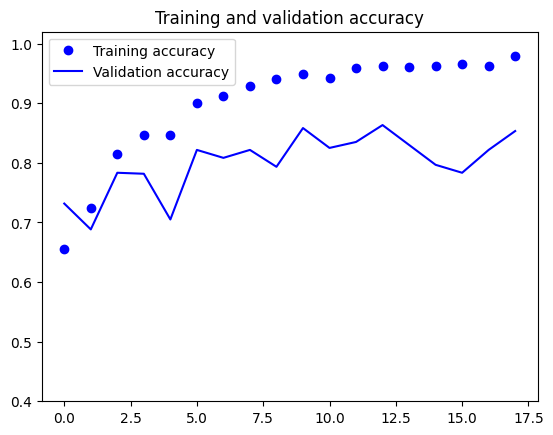

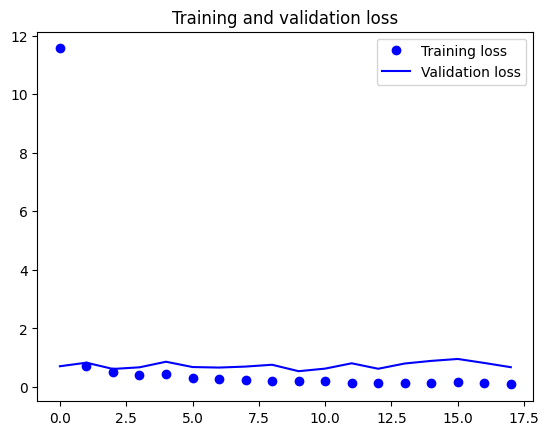

In [ ]:
import matplotlib.pyplot as plt


accuracy = landscapes_train.history['accuracy']
val_accuracy = landscapes_train.history['val_accuracy']
loss = landscapes_train.history['loss']
val_loss = landscapes_train.history['val_loss']
epochs = range(len(accuracy))

# Gráfica de accuracy
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.ylim(0.4, 1.02)  # Ajusta los límites del eje Y de 0 a 1
plt.legend()
plt.figure()

# Gráfica de loss
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
#plt.ylim(-0,  )  # Ajusta los límites del eje Y basado en los valores de pérdida
plt.legend()
plt.show()

In [ ]:
predicted_classes = landscapes_model.predict(test_X)
predicted_classes = np.argmax(np.round(predicted_classes),axis=1)
test_Y_flat = np.argmax(test_Y, axis=1)
predicted_classes.shape, test_Y_flat.shape

19/19 [==============================] - 0s 19ms/step


((600,), (600,))

In [ ]:
from sklearn.metrics import classification_report
target_names = ["Class {}".format(i) for i in range(num_classes)]
print(classification_report(test_Y_flat, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.84      0.85      0.85       200
     Class 1       0.92      0.88      0.90       200
     Class 2       0.90      0.92      0.91       200

    accuracy                           0.89       600
   macro avg       0.89      0.88      0.89       600
weighted avg       0.89      0.89      0.89       600



In [ ]:
#Martriz de Confusion

test_predictions = landscapes_model.predict(test_X)
test_predicted_classes = np.argmax(test_predictions, axis=1)
true_classes = np.argmax(test_Y, axis=1)

19/19 [==============================] - 0s 21ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matrix = confusion_matrix(true_classes, test_predicted_classes)

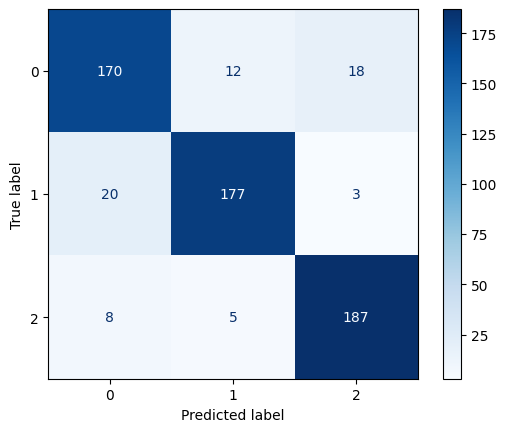

In [ ]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()